In [1]:
%load_ext cuml.accel
%run /mnt/d/Users/Admin/Projects/dso/SAR_ML/notebooks/SSR/SSRtransforms_updated.py
import os
import random
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.optim.lr_scheduler import CosineAnnealingLR, OneCycleLR
from torch.utils.data import DataLoader
import re
import copy
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap.umap_ as umap

2026-03-22 18:46:33.182917: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-22 18:46:33.722380: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-22 18:46:35.492869: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-22 18:46:35.498137: I external/local_xla/xla/tsl/cuda/cudart

In [2]:
def set_seed(seed=42):
    """Set all random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # Uncomment only if you need 100% determinism and can handle errors
    # torch.use_deterministic_algorithms(True, warn_only=True)
    # os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
    
    os.environ["PYTHONHASHSEED"] = str(seed)

def worker_init_fn(worker_id):
    """DataLoader worker init for reproducibility"""
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

In [3]:
# workspace = "/workspace/alvin/SAR_ML"
workspace = "/mnt/d/Users/Admin/Projects/dso/SAR_ML"
data_workspace = os.path.join(workspace, "data/SAMPLE")
clutter_dir = os.path.join(workspace, "data/MSTAR/CLUTTER/15_DEG")

In [4]:
synth_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/synth"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

meas_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)
clutter_cache = build_clutter_cache(meas_ds, clutter_dir)

Building clutter cache: 100%|███████████████████████████████████████████████████████| 1345/1345 [04:30<00:00,  4.97it/s]


In [5]:
meas_ds_s2 = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions=(".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), Scenario2Merging(clutter_cache), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

In [6]:
seed_lst = [10, 42, 100, 123, 666, 777, 849, 1000, 1111, 1234]

In [7]:
# Evaluate all 10 trained models on test set
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
test_acc_lst = []
for i, seed in enumerate(seed_lst):
    print(f"Evaluating Run {i}: seed {seed}")
    new_model = models.resnet18(weights = None) # dont load ImageNet Weights
    new_model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(new_model.fc.in_features, len(synth_ds.class_to_idx))
    )
    
    # Load your trained weights
    new_model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/Experiment_1/SSR_exp1_full_runs/rn18_seed{seed}_b16.pth"),
        map_location=device
    ))
    
    new_model = new_model.to(device)
    new_model.eval()

    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in DataLoader(meas_ds_s2, batch_size=16, shuffle=False, num_workers=12, pin_memory = True, persistent_workers=True):
            inputs = inputs.to(device)
            labels = labels.to(device)
    
            outputs = new_model(inputs)
            _, preds = torch.max(outputs, 1)
    
            correct += torch.sum(preds == labels).item()
            total += labels.size(0)
    
    test_acc = correct / total
    print(f"Test Accuracy: {test_acc:.4f}")
    test_acc_lst.append(test_acc)

Evaluating Run 0: seed 10
Test Accuracy: 0.8491
Evaluating Run 1: seed 42
Test Accuracy: 0.8535
Evaluating Run 2: seed 100
Test Accuracy: 0.8468
Evaluating Run 3: seed 123
Test Accuracy: 0.8312
Evaluating Run 4: seed 666
Test Accuracy: 0.7822
Evaluating Run 5: seed 777
Test Accuracy: 0.8230
Evaluating Run 6: seed 849
Test Accuracy: 0.8387
Evaluating Run 7: seed 1000
Test Accuracy: 0.8387
Evaluating Run 8: seed 1111
Test Accuracy: 0.8416
Evaluating Run 9: seed 1234
Test Accuracy: 0.8513


In [8]:
test_acc_arr = np.array(test_acc_lst)
print(f"Min: {test_acc_arr.min() * 100:.4f}")
print(f"Max: {test_acc_arr.max() * 100:.4f}")
print(f"Avg, Std: {test_acc_arr.mean() * 100:.4f}, {test_acc_arr.std() * 100:.4f}")

Min: 78.2156
Max: 85.3532
Avg, Std: 83.5613, 1.9910


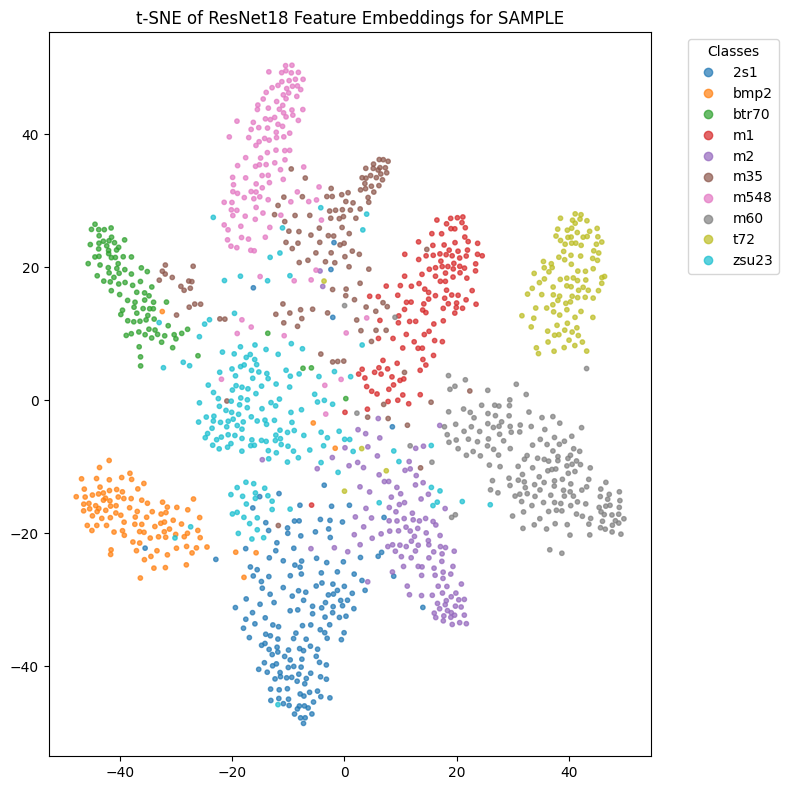

In [9]:
new_model = models.resnet18(weights = None) # dont load ImageNet Weights
# new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
new_model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(new_model.fc.in_features, len(synth_ds.class_to_idx))
    )
# Load your trained weights
new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/Experiment_1/SSR_exp1_full_runs/rn18_seed{seed}_b16.pth"),
    map_location=device
))

new_model = new_model.to(device)
new_model.eval()

feature_extractor = nn.Sequential(*list(new_model.children())[:-1])
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

features, labels_list = [], []

with torch.no_grad():
    for inputs, targets in DataLoader(meas_ds_s2, batch_size=16, shuffle=False, num_workers=12, pin_memory = True, persistent_workers=True):
        inputs = inputs.to(device)
        feats = feature_extractor(inputs)
        feats = feats.view(feats.size(0), -1)
        features.append(feats.cpu())
        labels_list.append(targets)

features = torch.cat(features).numpy()
labels_list = torch.cat(labels_list).numpy()

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    n_jobs=-1
)

features_2d = tsne.fit_transform(features)

# Get class names from the dataset
class_names = [name for name, idx in sorted(synth_ds.class_to_idx.items(), key=lambda x: x[1])]

plt.figure(figsize=(8, 8))
scatter = plt.scatter(
    features_2d[:, 0],
    features_2d[:, 1],
    c=labels_list,
    cmap="tab10",
    s=10,
    alpha=0.7
)

plt.legend(
    handles=scatter.legend_elements()[0],
    labels=class_names,
    title="Classes",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.title("t-SNE of ResNet18 Feature Embeddings for SAMPLE")
plt.tight_layout()
plt.show()

/home/alvinng44/.local/share/mamba/envs/alyssa/lib/python3.12/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


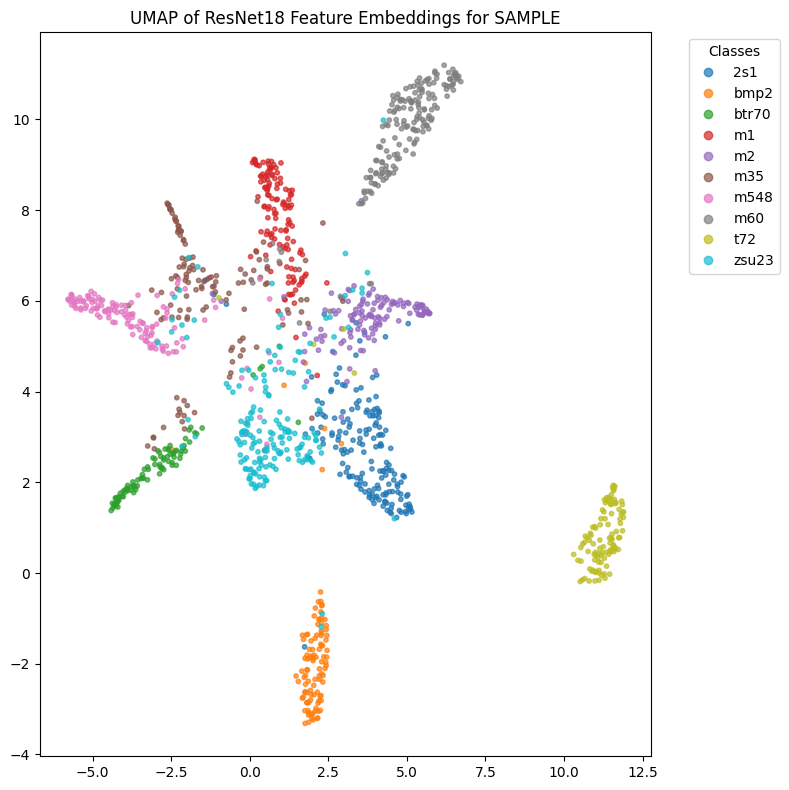

In [10]:
new_model = models.resnet18(weights = None) # dont load ImageNet Weights
# new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
new_model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(new_model.fc.in_features, len(synth_ds.class_to_idx))
    )
# Load your trained weights
new_model.load_state_dict(torch.load(
    os.path.join(workspace, f"weights/SSR/Experiment_1/SSR_exp1_full_runs/rn18_seed{seed}_b16.pth"),
    map_location=device
))

new_model = new_model.to(device)
new_model.eval()

feature_extractor = nn.Sequential(*list(new_model.children())[:-1])
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

features, labels_list = [], []

with torch.no_grad():
    for inputs, targets in DataLoader(meas_ds_s2, batch_size=16, shuffle=False, num_workers=12, pin_memory = True, persistent_workers=True):
        inputs = inputs.to(device)
        feats = feature_extractor(inputs)
        feats = feats.view(feats.size(0), -1)
        features.append(feats.cpu())
        labels_list.append(targets)

features = torch.cat(features).numpy()
labels_list = torch.cat(labels_list).numpy()

reducer = umap.UMAP(
    n_neighbors=30,
    min_dist=0.25,
    n_components=2,
)

features_2d_umap = reducer.fit_transform(features)

# Get class names from the dataset
class_names = [name for name, idx in sorted(synth_ds.class_to_idx.items(), key=lambda x: x[1])]

plt.figure(figsize=(8, 8))
scatter = plt.scatter(
    features_2d_umap[:, 0],
    features_2d_umap[:, 1],
    c=labels_list,
    cmap="tab10",
    s=10,
    alpha=0.7
)

plt.legend(
    handles=scatter.legend_elements()[0],
    labels=class_names,
    title="Classes",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.title("UMAP of ResNet18 Feature Embeddings for SAMPLE")
plt.tight_layout()
plt.show()

In [7]:
save_dir = os.path.join(workspace, "images", "comparison")
os.makedirs(save_dir, exist_ok=True)

for idx in tqdm(range(len(meas_ds)), desc="Saving plots"):
    
    tensor1, label1 = meas_ds[idx]
    image1 = tensor1[0].numpy()  # (3, 128, 128) -> (128, 128)
    class_name1 = meas_ds.classes[label1]

    tensor2, label2 = meas_ds_s2[idx]
    image2 = tensor2[0].numpy()  # (3, 128, 128) -> (128, 128)
    class_name2 = meas_ds_s2.classes[label2]
    
    fig = plt.figure(figsize = (10, 4))
    
    ax1 = fig.add_subplot(1, 2, 1)
    ax1.imshow(image1, cmap='gray')
    ax1.set_title(f"sample clutter")
    ax1.axis('off')

    ax2 = fig.add_subplot(1, 2, 2)
    ax2.imshow(image2, cmap='gray')
    ax2.set_title(f"mstar clutter")
    ax2.axis('off')

    if class_name1 == class_name2:
        save_path = os.path.join(save_dir, f"{idx:04d}_{class_name1}.png")
        plt.savefig(save_path, bbox_inches='tight', dpi=80)
        plt.close(fig)

print(f"Saved {len(meas_ds)} images to {save_dir}")

Saving plots: 100%|█████████████████████████████████████████████████████████████████| 1345/1345 [06:18<00:00,  3.55it/s]

Saved 1345 images to /mnt/d/Users/Admin/Projects/dso/SAR_ML/images/comparison
